In [2]:
import torch

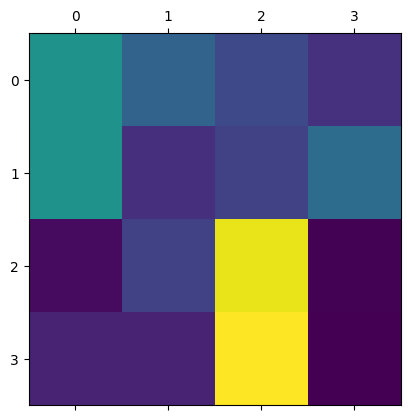

In [251]:
from matplotlib import pyplot as plt
import numpy as np

def generate_W(n: int):

    W = np.random.random((n, n))
    w_sum = np.sum(W, axis=1, keepdims=True)
    return W / w_sum


n = 4
W = generate_W(n)

plt.matshow(W)

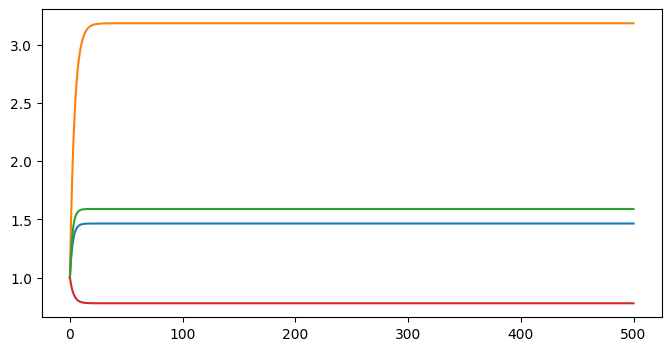

In [10]:
def step(P: np.ndarray, W: np.ndarray):

    new_P = np.zeros_like(P)
    W = np.copy(W)
    np.fill_diagonal(W, 0)

    outgoing = np.sum(W, axis=1)
    incoming = np.sum(W, axis=0)

    for i_classifier, (Pi, inc, out) in enumerate(zip(P, incoming, outgoing, strict=True)):
        new_P[i_classifier] = out * (Pi + inc)

    return new_P


def solve(P0: np.ndarray, W: np.ndarray, steps: int):

    Ps = [P0]
    P = P0
    for _ in range(steps):
        P = step(P, W)
        Ps.append(P)

    return np.array(Ps)


P0 = np.ones(n)
Ps = solve(P0, W, 500)

fig, ax  = plt.subplots(figsize=(8, 4))

for i_classifier in range(Ps.shape[1]):
    ax.plot(Ps[:, i_classifier])

In [84]:
def generate_W(n: int):

    W = np.random.random((n, n))
    w_sum = np.sum(W, axis=1, keepdims=True)
    return W / w_sum


def generate_W_w(n: int):
    # Sample intrinsic self-vote weights for each voter
    alphas = np.random.rand(n)  # α_i in [0,1] for each voter i

    # Initialize a matrix for delegation probabilities.
    # For each voter j, we will generate a probability distribution over all i ≠ j.
    p = np.zeros((n, n))
    for j in range(n):
        # Get indices for "other" voters (excluding self)
        others = [i for i in range(n) if i != j]
        # Generate random positive numbers for these indices
        rand_vals = np.random.rand(len(others))
        # Normalize so that they sum to 1
        p[j, others] = rand_vals / rand_vals.sum()

    # Now, each voter j delegates a fraction (1 - α_j) of their vote according to p[j, :].
    # In our fixed point equation, we want:
    #   x_i = α_i + Σ_j (1-α_j)*p[j, i] * x_j.
    # So define a matrix M where M[j, i] = (1-α_j)*p[j, i].
    M = (1 - alphas)[:, np.newaxis] * p  # shape (n, n)

    # For the fixed point equation in the form x = w + W x, we want W[i, j]
    # to represent the delegation contribution from voter j to voter i.
    # That is, we set:
    #    W[i, j] = (1-α_j)*p[j, i]   <=>   W = M^T.
    W = M.T

    # Return W and the intrinsic weights vector (w = alphas)
    return W, alphas

n = 4
W, w = generate_W_w(n)

def solve_fixed_point(W: np.ndarray, w: np.ndarray):

    W = np.copy(W.T)
    np.fill_diagonal(W, 0)
    stable = np.linalg.pinv(np.identity(W.shape[0]) - W) @ w[:, np.newaxis]

    return np.squeeze(stable)

solve_fixed_point(W, w)

array([1., 1., 1., 1.])

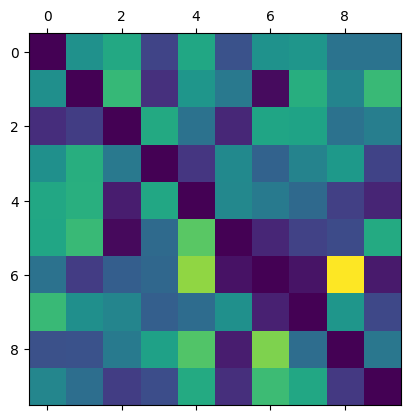

In [222]:
def generate_W_p(n: int):

    W = np.random.random((n, n))
    w_sum = np.sum(W, axis=1, keepdims=True)
    W =  W / w_sum

    p = np.diag(np.copy(W))
    np.fill_diagonal(W, 0)

    return W, p

W, p = generate_W_p(10)
plt.matshow(W)

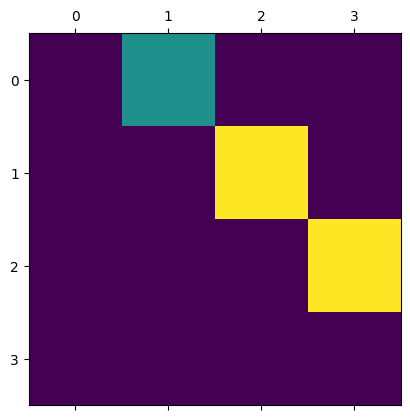

In [416]:
W = np.array([
    [0, 0.5, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1],
    [0, 0, 0, 1],
], dtype=float)

p = np.ones(W.shape[0])
np.fill_diagonal(W, 0.0)

plt.matshow(W)

In [418]:
import numpy as np


def step(p: np.ndarray, W: np.ndarray):
    out = np.sum(W, axis=1)
    incoming = np.dot(W.T, p)
    new_p = (1 - out) * p + incoming
    return new_p

def solve_iterative(W: np.ndarray, p: np.ndarray, iterations: int = 100):
    for _ in range(iterations):
        p = step(p, W)
    return p

print(solve_iterative(W, p))


[7.88860905e-31 7.88860905e-31 1.57772181e-30 4.00000000e+00]


In [244]:
import numpy as np
import matplotlib.pyplot as plt

def step(p_delegatable, p_kept, W):
    n = len(p_delegatable)

    new_delegatable = np.zeros_like(p_delegatable)
    new_kept = p_kept.copy()

    outgoing_sums = np.sum(W, axis=1) - np.diag(W)

    keep_amount = np.diag(W) * p_delegatable
    outflow = p_delegatable - keep_amount

    new_kept += keep_amount

    # Distribute the outflow to other voters proportionally:
    for i in range(n):
        outgoing_sum = outgoing_sums[i]
        if outgoing_sum > 0:
            # If there's some fraction going out, distribute among j != i
            for j in range(n):
                if (j == i) or W[i, j] <= 0:
                    continue

                frac = W[i,j] / outgoing_sum
                incoming_j = frac * outflow[i]
                new_delegatable[j] += incoming_j
        else:
            # If row_sums_offdiag[i] == 0, then i doesn't delegate to others
            # (maybe i is a 'full sink' => W[i,i] = 1 or the row is all 0)
            # so i effectively keeps all leftover
            new_kept[i] += outflow[i]

    return new_delegatable, new_kept

import numpy as np

def vectorized_step(p_delegatable, p_kept, W):

    keep_amount = np.diag(W) * p_delegatable
    outflow = p_delegatable - keep_amount

    new_kept = p_kept + keep_amount

    # In torch Small positive constant is added to ensure there is always some delegations
    outgoing_sums = np.sum(W, axis=1) - np.diag(W)

    # This doesn't exist in the torch version
    # TODO inspect what it does in
    no_delegate = (outgoing_sums == 0)
    new_kept[no_delegate] += outflow[no_delegate]

    W_eff = W.copy()
    np.fill_diagonal(W_eff, 0)

    # This is deleted in torch since softmax is always positive
    W_eff[W_eff <= 0] = 0

    # This is deleted in torch since outgoing_sums is always positive
    denom = np.where(outgoing_sums > 0, outgoing_sums, 1)

    contribution = (W_eff / denom[:, None]) * outflow[:, None]

    new_delegatable = contribution.sum(axis=0)

    return new_delegatable, new_kept



import torch

def torch_step(p_delegatable, p_kept, W):

    diag_indices = torch.arange(n)

    # Get the diagonal elements of W: shape (batch_size, n)
    diag_W = W[:, diag_indices, diag_indices]

    # Compute the amount to keep
    keep_amount = diag_W * p_delegatable
    outflow = p_delegatable - keep_amount
    new_kept = p_kept + keep_amount

    # Sum each row of W and subtract the diagonal, adding a small epsilon for stability.
    outgoing_sums = W.sum(dim=2) - diag_W + 1e-6

    # Create an effective W with zeros on the diagonal.
    mask = torch.ones_like(W)
    mask[:, diag_indices, diag_indices] = 0

    W_eff = W * mask

    # Normalize each row of W_eff by its outgoing sum and weight by the outflow.
    # W_eff: (batch, n, n), outgoing_sums.unsqueeze(2): (batch, n, 1), outflow.unsqueeze(2): (batch, n, 1)
    contribution = (W_eff / outgoing_sums.unsqueeze(2)) * outflow.unsqueeze(2)

    # Sum contributions over the rows to get the new delegatable values (for each target node).
    new_delegatable = contribution.sum(dim=1)

    return new_delegatable, new_kept


def solve_iterative(W, p_init, step_fun, max_iter=1000, tol=1e-4):

    p_delegatable = p_init.astype(float).copy()
    p_kept = np.zeros_like(p_delegatable)

    for i_iter in range(max_iter):
        old_sum = p_delegatable.sum() + p_kept.sum()

        new_delegatable, new_kept = step_fun(p_delegatable, p_kept, W)
        new_sum = new_delegatable.sum() + new_kept.sum()

        # Check that total power is conserved (up to float epsilon)
        if not np.isclose(old_sum, new_sum, atol=1e-9):
            print(f"Warning: total power changed from {old_sum} to {new_sum}")

        # Check for convergence
        if (np.allclose(new_delegatable, p_delegatable, atol=tol) and
            np.allclose(new_kept, p_kept, atol=tol)):
            # print("Converged", i_iter)
            return new_delegatable + new_kept

        p_delegatable, p_kept = new_delegatable, new_kept

    return p_delegatable + p_kept


def solve_iterative_torch(W, max_iter=100, tol=1e-4):

    p_delegatable = torch.ones((W.shape[0], W.shape[1]), device="cuda", dtype=torch.double)
    p_kept = torch.zeros_like(p_delegatable)

    for i_iter in range(max_iter):
        old_sum = p_delegatable.sum() + p_kept.sum()

        new_delegatable, new_kept = torch_step(p_delegatable, p_kept, W)
        new_sum = new_delegatable.sum() + new_kept.sum()

        if not torch.isclose(old_sum, new_sum, atol=1e-6):
            print(f"Warning: total power changed from {old_sum.item()} to {new_sum.item()}")

        if (torch.allclose(new_delegatable, p_delegatable, atol=tol) and
            torch.allclose(new_kept, p_kept, atol=tol)):
            # print("Converged", i_iter)
            return new_delegatable + new_kept

        p_delegatable, p_kept = new_delegatable, new_kept

    return p_delegatable + p_kept


W = np.array([
    [0.0, 1.0, 0.0, 0.0],
    [0.0, 0.0, 1.0, 0.0],
    [1.0, 0.0, 0.0, 0.0],
    [0.0, 0.5, 0.0, 0.5],
])


n = 4
W = np.random.random((n, n))
w_sum = np.sum(W, axis=1, keepdims=True)
W =  W / w_sum

# plt.matshow(W)

p_init = np.array([1,1,1,1], dtype=float)
p_vector = solve_iterative(W, p_init, vectorized_step)
p_init = np.array([1,1,1,1], dtype=float)
p_loop = solve_iterative(W, p_init, step)

W_torch = torch.tensor(W, device="cuda", dtype=torch.double, requires_grad=True).unsqueeze(0)
p_torch = solve_iterative_torch(W_torch)
p_torch = torch.squeeze(p_torch).detach().cpu().numpy()
delta = np.abs(p_torch - p_loop)

print(p_loop, p_torch)
print(np.max(delta), np.mean(delta))
# np.max(np.abs((p_vector_del + p_vector_kept) - (p_loop_del + p_loop_kept)))

# print("Final delegatable =", p_delegatable_final)
# print("Final kept        =", p_kept_final)
# print("\nFinal             =", p_kept_final  + p_delegatable_final)
# print("Total power       =", p_delegatable_final.sum() + p_kept_final.sum())


[2.13396841 0.56168128 0.68459354 0.61975677] [2.13396011 0.56167971 0.68459083 0.61975449]
8.299694501001653e-06 3.716251602614573e-06


In [ ]:
W_torch = torch.tensor(W, device="cuda", dtype=torch.double, requires_grad=True)
p_torch = solve_iterative_torch(W_torch.unsqueeze(0), tol=1e-5)

p_torch[:, 0].sum().backward()
W_torch.grad

tensor([[ 6.9657, -0.0280,  0.3282, -0.0537],
        [ 0.1236, -1.3952, -0.1240, -0.3486],
        [ 0.2187, -0.2374, -1.2967, -0.2525],
        [ 0.1552, -0.4410, -0.1679, -1.8260]], device='cuda:0',
       dtype=torch.float64)

In [173]:
l = torch.rand((3, 4, 4))
diag = torch.arange(4)
print(l)
l[:, diag, diag]

tensor([[[0.3607, 0.0758, 0.4385, 0.9897],
         [0.7552, 0.7935, 0.6654, 0.9048],
         [0.9452, 0.8327, 0.3158, 0.8677],
         [0.6668, 0.8358, 0.1863, 0.3252]],

        [[0.4835, 0.5890, 0.2265, 0.8546],
         [0.2266, 0.8812, 0.4224, 0.9624],
         [0.2157, 0.2012, 0.0488, 0.0948],
         [0.1706, 0.5594, 0.0065, 0.8881]],

        [[0.9504, 0.3354, 0.4000, 0.6646],
         [0.3103, 0.2049, 0.3967, 0.1029],
         [0.1164, 0.0705, 0.6062, 0.7942],
         [0.8490, 0.3540, 0.6502, 0.4237]]])


tensor([[0.3607, 0.7935, 0.3158, 0.3252],
        [0.4835, 0.8812, 0.0488, 0.8881],
        [0.9504, 0.2049, 0.6062, 0.4237]])

In [9]:
%matplotlib qt

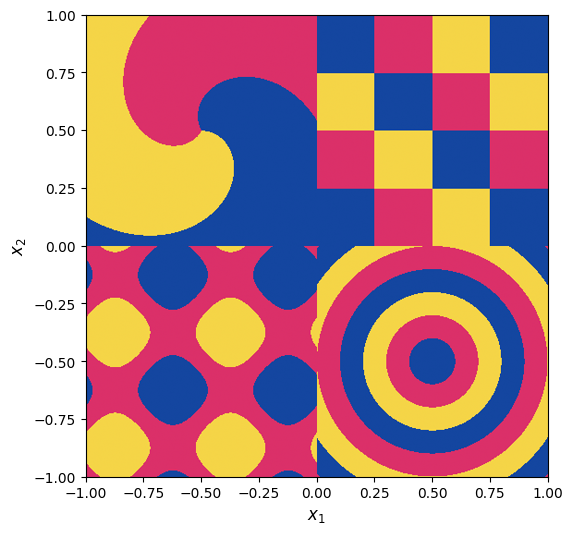

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Set resolution of the grid
N = 500
x = np.linspace(-1, 1, N)
y = np.linspace(-1, 1, N)
xx, yy = np.meshgrid(x, y)

# Prepare an array to hold the class labels
Z = np.zeros_like(xx, dtype=int)

# Define quadrant masks
mask_ul = (xx < 0) & (yy > 0)   # Upper Left: x < 0, y > 0
mask_ur = (xx >= 0) & (yy > 0)  # Upper Right: x >= 0, y > 0
mask_ll = (xx < 0) & (yy <= 0)  # Lower Left: x < 0, y <= 0
mask_lr = (xx >= 0) & (yy <= 0) # Lower Right: x >= 0, y <= 0

# ------------------------
# Upper Left: Spiral Pattern
# ------------------------
# For this quadrant, use the center (-0.5, 0.5)
dx = xx[mask_ul] + 0.5
dy = yy[mask_ul] - 0.5
r = np.sqrt(dx**2 + dy**2)
theta = np.arctan2(dy, dx)
# Add a twist proportional to the radius to create a spiral effect
total_angle = np.mod(theta + 4 * r, 2 * np.pi)
# Divide the circle into three equal segments
classes_ul = np.floor(total_angle / (2 * np.pi / 3)).astype(int)
Z[mask_ul] = classes_ul

# ------------------------
# Upper Right: Grid (Squares) Pattern
# ------------------------
# Here, the quadrant spans x in [0,1] and y in [0,1]
dx = xx[mask_ur]
dy = yy[mask_ur]
# Clip to avoid potential index overflow at the boundary
dx_clipped = np.clip(dx, 0, 0.9999)
dy_clipped = np.clip(dy, 0, 0.9999)
# Divide the quadrant into a 4x4 grid and assign class based on grid indices
i = np.floor(dx_clipped * 4).astype(int)
j = np.floor(dy_clipped * 4).astype(int)
classes_ur = (i + j) % 3
Z[mask_ur] = classes_ur

# ------------------------
# Lower Left: Sinusoidal Wave Pattern
# ------------------------
# Use local coordinates with center (-0.5, -0.5)
dx = xx[mask_ll] + 0.5
dy = yy[mask_ll] + 0.5
# Combine two sine waves
f = np.sin(4 * np.pi * dx) + np.sin(4 * np.pi * dy)
# Map the combined sine value (which lies between -2 and 2) into 3 classes
classes_ll = np.zeros_like(f, dtype=int)
classes_ll[f < -0.67] = 0
classes_ll[(f >= -0.67) & (f < 0.67)] = 1
classes_ll[f >= 0.67] = 2
Z[mask_ll] = classes_ll

# ------------------------
# Lower Right: Concentric Circles Pattern
# ------------------------
# Center at (0.5, -0.5)
dx = xx[mask_lr] - 0.5
dy = yy[mask_lr] + 0.5
r = np.sqrt(dx**2 + dy**2)
# Multiply the radius to set the frequency of the rings,
# then assign classes using floor and modulo 3 to cycle through classes.
classes_lr = (np.floor(r * 10).astype(int)) % 3
Z[mask_lr] = classes_lr

# ------------------------
# Plotting the Classification Map
# ------------------------
# Define a colormap: class 0->red, class 1->green, class 2->blue
cmap = ListedColormap(['#1446A0', '#DB3069', '#F5D547'])

plt.figure(figsize=(6, 6))
# Use imshow with a smooth interpolation so the colors fill the entire region
plt.imshow(Z, extent=[-1, 1, -1, 1], origin='lower', cmap=cmap, interpolation='spline16')
plt.xlabel("$x_1$", fontsize=12)
plt.ylabel("$x_2$", fontsize=12)
# plt.colorbar(ticks=[0, 1, 2], label='Class')
plt.savefig("./figures/synthetic.pdf")
plt.show()


In [3]:
import numpy as np
x, y = np.meshgrid([1, 2, 3], [2, 3, 4])
x.flatten(), y.flatten()

(array([1, 2, 3, 1, 2, 3, 1, 2, 3]), array([2, 2, 2, 3, 3, 3, 4, 4, 4]))

In [ ]:
import random
import string

def replace_random_chars(text: str, p: float) -> str:
    if not (0 <= p <= 1):
        raise ValueError("p must be between 0 and 1")

    text_list = list(text)
    non_space_indices = [i for i, char in enumerate(text_list) if char != ' ']
    num_replacements = int(len(non_space_indices) * p)

    for i in random.sample(non_space_indices, num_replacements):
        text_list[i] = random.choice(string.ascii_letters)

    return ''.join(text_list)

# Example usage
text = "How is it possible that you can rexognize this text?"
p = 0.4
modified_text = replace_random_chars(text, p)
print(modified_text)

How iX it possibgz that xog VYz rPxFOniwe jhms tyxtA


In [246]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Button

class InteractiveW:
    def __init__(self, n=4):
        self.n = n
        self.W = np.zeros((n, n))
        self.fig, self.ax = plt.subplots(figsize=(6, 6))
        plt.subplots_adjust(bottom=0.2)
        self.im = self.ax.imshow(self.W, cmap="gray", vmin=0, vmax=1)
        self.ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
        self.ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
        self.ax.grid(which="minor", color="black", linestyle='-', linewidth=2)
        self.ax.tick_params(which="both", bottom=False, left=False, labelbottom=True, labelleft=True)
        self.fig.canvas.mpl_connect("button_press_event", self.onclick)
        button_ax = self.fig.add_axes([0.8, 0.05, 0.15, 0.075])
        self.button = Button(button_ax, "Calculate")
        self.button.on_clicked(self.calculate)
        self.res_ax = self.fig.add_axes([0.1, 0.05, 0.65, 0.075])
        self.res_ax.axis("off")
        self.result_text = self.res_ax.text(0.5, 0.5, "",
                                              horizontalalignment="center",
                                              verticalalignment="center",
                                              transform=self.res_ax.transAxes,
                                              fontsize=12)

    def onclick(self, event):
        # Ensure the click occurred in our matrix axes and that xdata/ydata are defined.
        if event.inaxes != self.ax or event.xdata is None or event.ydata is None:
            return

        # Use rounding to identify the closest cell center
        col = int(np.rint(event.xdata))
        row = int(np.rint(event.ydata))
        if 0 <= row < self.n and 0 <= col < self.n:
            current = self.W[row, col]

            if event.button == 1:
                add = 0.5
            else:
                add = 0.25

            current += add
            if current > 1.0:
                current = 0

            self.W[row, col] = current
            self.im.set_data(self.W)
            self.fig.canvas.draw_idle()

    def calculate(self, event):
        p_init = np.ones(self.n)
        p_delegate, p_kept = solve_iterative(self.W, p_init, solve_iterative)
        p_final = p_kept + p_delegate
        result_str = f"{p_final.sum():.2f} " + np.array2string(p_final, precision=3)
        self.result_text.set_text(result_str)
        self.fig.canvas.draw_idle()

demo = InteractiveW(n=4)
plt.show()


Traceback (most recent call last):
  File "c:\Users\viktor\Documents\liquid\liquid\Lib\site-packages\matplotlib\cbook.py", line 361, in process
    func(*args, **kwargs)
  File "c:\Users\viktor\Documents\liquid\liquid\Lib\site-packages\matplotlib\widgets.py", line 244, in <lambda>
    return self._observers.connect('clicked', lambda event: func(event))
                                                            ^^^^^^^^^^^
  File "C:\Users\viktor\AppData\Local\Temp\ipykernel_14516\1708121637.py", line 54, in calculate
    p_delegate, p_kept = solve_iterative(self.W, p_init, solve_iterative)
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\viktor\AppData\Local\Temp\ipykernel_14516\642333576.py", line 112, in solve_iterative
    new_delegatable, new_kept = step_fun(p_delegatable, p_kept, W)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\viktor\AppData\Local\Temp\ipykernel_14516\642333576.py", line 112, in solv

In [351]:
def solve_fixed_point(W: np.ndarray, p: np.ndarray):

    alpha = 0.9

    W = alpha * np.copy(W.T)
    np.fill_diagonal(W, 0)
    inv = np.linalg.pinv(np.identity(W.shape[0]) - W)
    stable = inv @ (p[:, np.newaxis])

    return np.squeeze(stable)

solve_fixed_point(W, p + np.ones(W.shape[0]))

array([10., 10.,  2.,  2.])

In [ ]:
from torch.distributions import Categorical
import math

n = 12
histogram = torch.bincount(torch.randint(0, n, (100,)))

print(histogram)
dist = Categorical(probs=histogram / histogram.sum())
dist.entropy() / math.log(n)

tensor([ 4,  6, 13, 10, 11, 11,  6,  7,  6,  7, 11,  8])


tensor(0.9793)

In [187]:
import torch

bs = 15
n = 4

Ds = [torch.rand((bs, n), requires_grad=True) for _ in range(n)]
Ds_cat_ready = [torch.unsqueeze(d, -1) for d in Ds]
D = torch.cat(Ds_cat_ready, dim=-1)

p = torch.diagonal(D, dim1=-2, dim2=-1)
mask = torch.ones_like(D)
mask = torch.ones_like(D)
batch_indices = torch.arange(bs).unsqueeze(1).unsqueeze(2)
diag_indices = torch.arange(n).unsqueeze(0).expand(n, -1)
mask[batch_indices, diag_indices, diag_indices] = 0
D_no_diag = D * mask

identity = torch.zeros_like(D)
identity[batch_indices, diag_indices, diag_indices] = 1

p_column = p.unsqueeze(-1)
inverse = torch.pinverse(identity - D_no_diag)
influence = torch.bmm(inverse, p_column)
influence = torch.squeeze(influence)

influence.sum().backward()
Ds[0].grad

tensor([[-2.1357e+00,  3.6265e+00,  1.1176e+00,  3.6910e+00],
        [-8.3647e+00,  6.5824e+00,  2.1243e+00,  6.4119e+00],
        [-1.1760e+00,  8.4928e-01,  1.8983e-01,  7.9119e-01],
        [-2.1929e+00,  8.7414e-01,  7.1433e-01,  1.5521e+00],
        [-2.1542e+00,  2.7343e+00,  2.7598e+00,  3.0652e+00],
        [-1.3913e+00,  1.0445e+00,  1.4449e+00,  7.3552e-01],
        [-2.4541e+01,  3.2504e+02,  3.9021e+02,  6.3721e+02],
        [-1.4137e+00,  1.6525e+00,  1.4320e+00,  5.8267e-01],
        [-5.3871e+00,  2.0789e+01,  1.7634e+01,  1.3988e+01],
        [-1.8161e+01,  1.0851e+02,  5.6026e+01,  7.1462e+01],
        [-1.2609e+00,  1.7677e+00,  6.3777e-01,  1.3811e+00],
        [-2.5434e+00,  4.7205e+00,  5.7598e+00,  7.4937e+00],
        [-8.0925e+01,  5.8892e+02,  6.2427e+02,  8.4758e+02],
        [-5.5893e+00,  1.3715e+01,  7.0365e+00,  6.3492e+00],
        [-3.8388e+00,  3.6738e+00,  6.0307e+00,  4.9316e+00]])

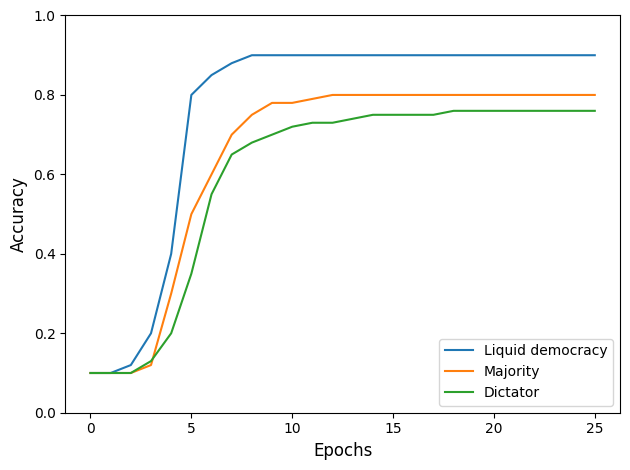

In [6]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(26)
liquid   = [0.1,0.1,0.12,0.2,0.4,0.8,0.85,0.88,0.90,0.90,0.90,0.90,0.90,0.90,0.90,0.90,0.90,0.90,0.90,0.90,0.90,0.90,0.90,0.90,0.90,0.90]
majority = [0.1,0.1,0.10,0.12,0.30,0.50,0.60,0.70,0.75,0.78,0.78,0.79,0.80,0.80,0.80,0.80,0.80,0.80,0.80,0.80,0.80,0.80,0.80,0.80,0.80,0.80]
dictator = [0.1,0.1,0.10,0.13,0.20,0.35,0.55,0.65,0.68,0.70,0.72,0.73,0.73,0.74,0.75,0.75,0.75,0.75,0.76,0.76,0.76,0.76,0.76,0.76,0.76,0.76]

liquid = np.array(liquid)
majority = np.array(majority)
dictator = np.array(dictator)

fig, ax = plt.subplots()

ax.plot(x, liquid,   label='Liquid democracy')
ax.plot(x, majority, label='Majority')
ax.plot(x, dictator, label='Dictator')
ax.set_xlabel("Epochs", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)

ax.set_ylim(0, 1)
ax.legend()

fig.tight_layout()


plt.show()
fig.savefig("./figures/preresults.pdf")
